# Final hypothesis test

In [65]:
animals_copy

,Animal_Type,Breed,Age,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,...,Wool_Reduce,Milk_Reduce,Lethargy,Weight_Loss,Swelling,Dehydration,Sneezing,Heart_Rate,Body_Temperature_°C,Disease_Prediction
0,1,1.11,4,25.0,1,1,0,0,0,0,...,0,0,1,0,0,0,0,120,39.5,1
1,2,2.04,2,4.5,0,0,0,1,0,0,...,0,0,0,0,0,0,1,150,38.9,2
2,3,3.02,3,600.0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,90,40.1,3
3,1,1.01,1,10.0,1,1,1,0,0,0,...,0,0,1,0,0,0,0,130,39.2,4
4,2,2.02,5,3.8,1,0,0,0,0,0,...,0,0,1,0,0,0,0,160,38.7,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,1,1.03,5,35.0,1,1,0,1,0,0,...,0,0,1,0,0,0,0,110,39.2,15
417,1,1.11,4,30.0,1,1,0,1,0,0,...,0,0,1,0,0,0,0,100,39.2,15
418,2,2.02,3,5.0,1,1,0,1,0,0,...,0,0,0,0,0,0,1,110,39.1,36
419,4,4.02,5,450.0,1,0,0,1,1,1,...,0,0,0,0,1,0,0,110,39.4,32


## Hypothesis: 'Age' and 'Weight' features are not important

### Last research before deadline of project(Body_Temperature)

In [66]:
animals_copy[animals_copy['Animal_Type'] == 1][['Fever', 'Body_Temperature_°C']][animals_copy['Fever'] == 0]

,Fever,Body_Temperature_°C
3,0,39.2
8,0,40.0
11,0,39.4
15,0,39.1
22,0,39.1
31,0,39.6
39,0,39.5
41,0,39.2
49,0,39.3
53,0,39.1


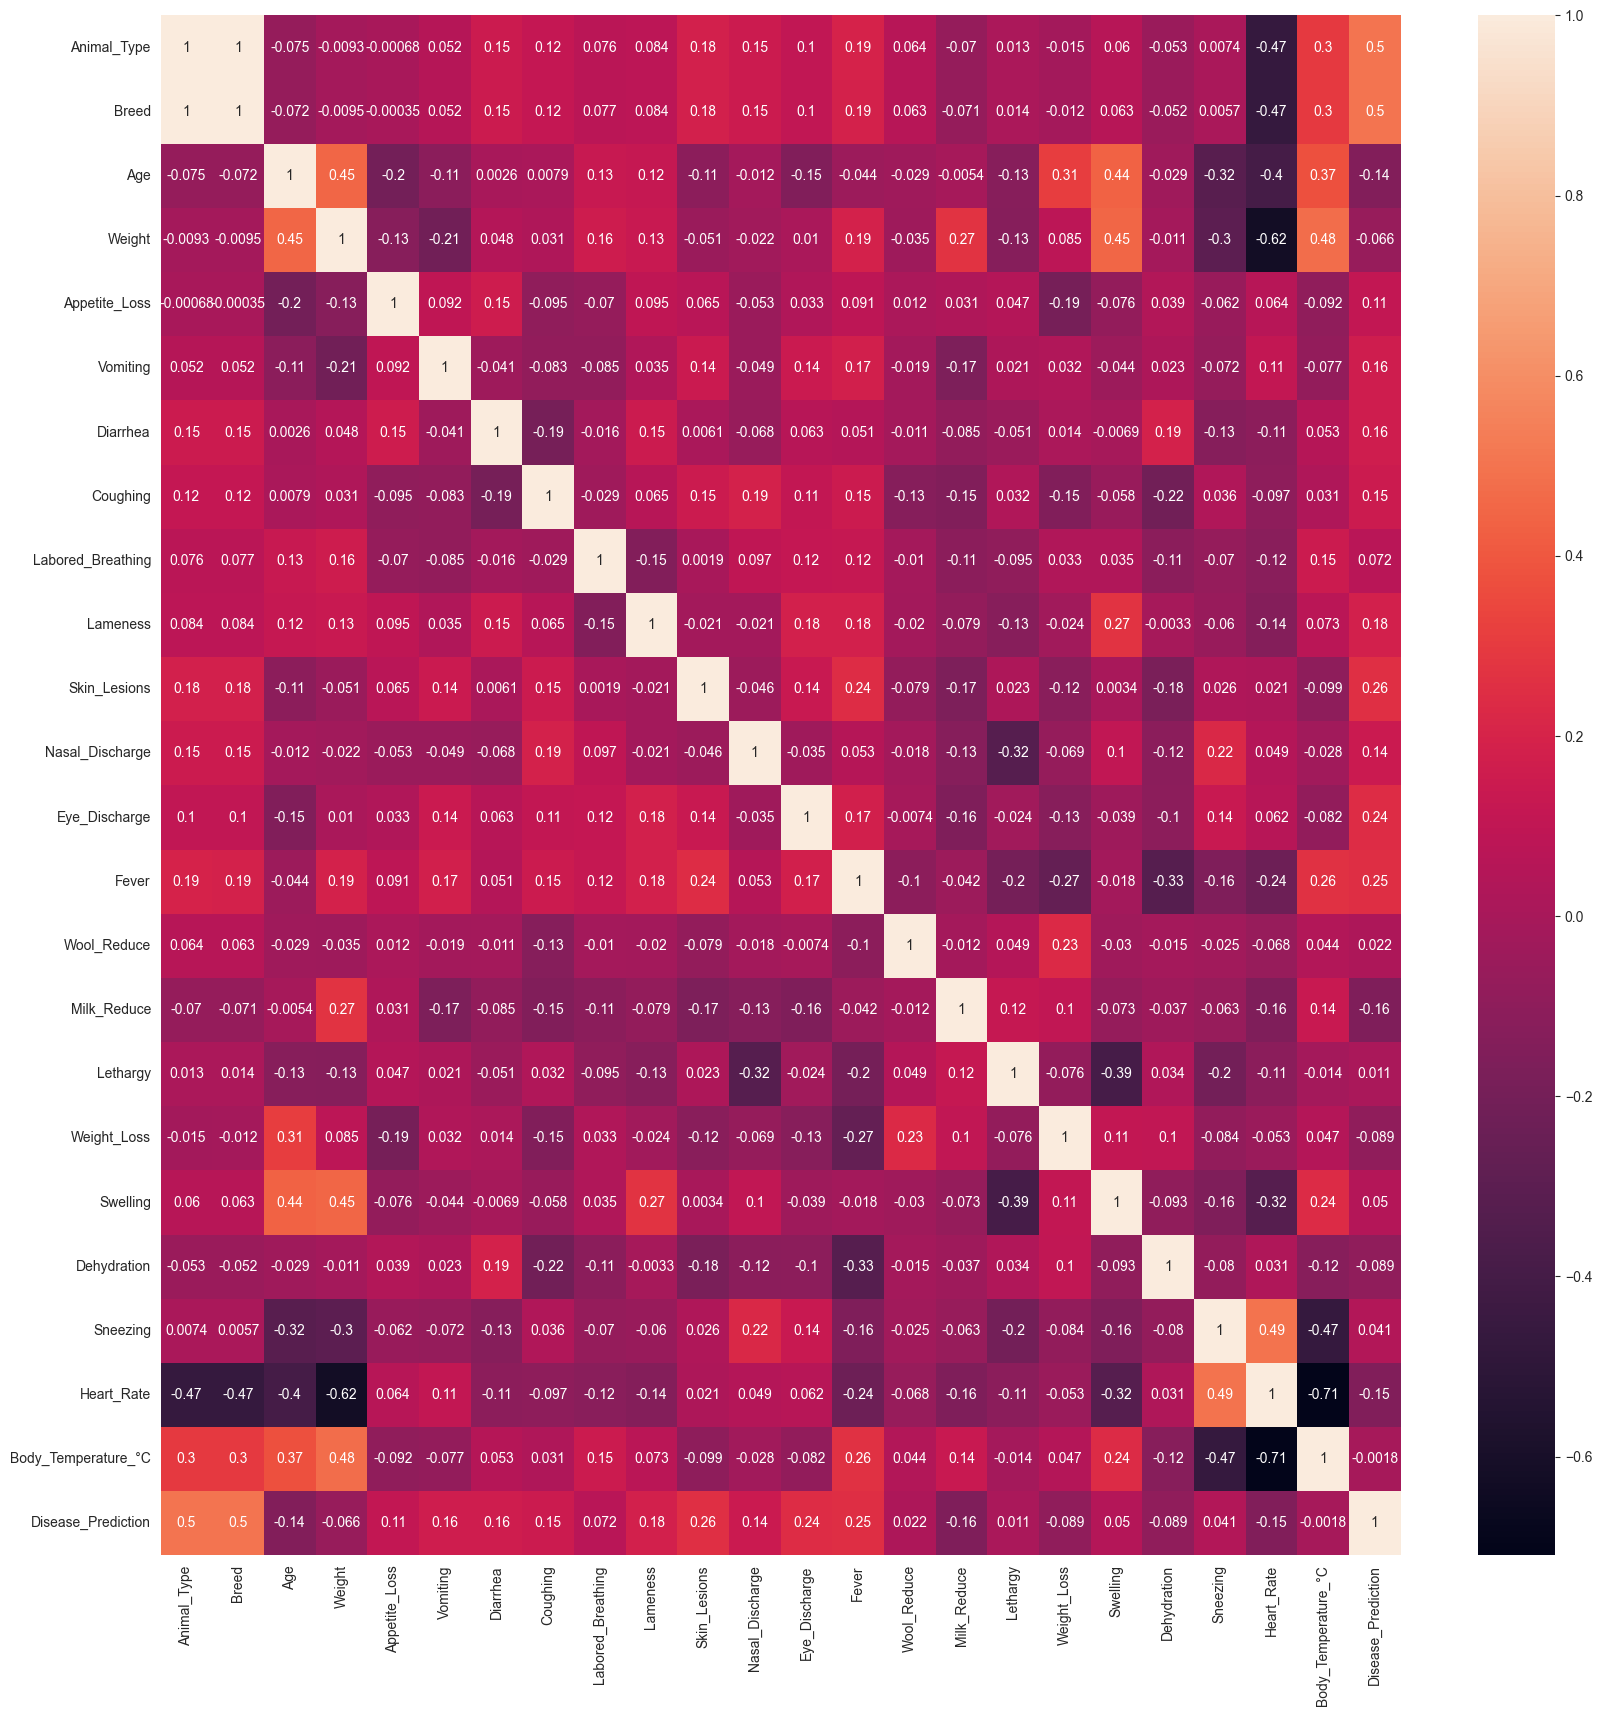

In [67]:
corr_m = animals_copy.corr()

plt.figure(figsize=(20, 20))

sns.heatmap(corr_m, annot=True)

plt.show()

In [68]:
'''Result of research is that the 'Body_Temperature_°C' feature have incorrect data and not correspond 'Fever' symptom. Delete!!!'''

"Result of research is that the 'Body_Temperature_°C' feature have incorrect data and not correspond 'Fever' symptom. Delete!!!"

## Correct extension way of dataset with maintaining distribution

In [69]:
a_copy = animals_copy.copy()

In [70]:
'''
Main idea for extension of dataset is extends dataset to 10x size. 
For each disease we'll take from whole dataset only samples which has specify disease (assume dataset 'main'). 
Next one is take random instances with random features of the same size and the same 'Animal_Type' (assume dataset 'random').
Resulting set will have form 'random'['Animal_Type', 'Breed', 'Age', 'Weight'] + 'main'[all symptoms + target feature] * 10.
'''

from random import choice

extended_animals = pd.DataFrame({}, columns=a_copy.columns)
for dis in a_copy['Disease_Prediction'].unique():
    spec_part = a_copy[a_copy['Disease_Prediction'] == dis]
    for _ in range(10):
        a = choice(spec_part['Animal_Type'].unique())
        inst = a_copy[a_copy['Animal_Type'] == a].sample(spec_part.shape[0], ignore_index=True, random_state=np.random.randint(15, 12345))
        inst = inst[['Animal_Type', 'Breed', 'Age', 'Weight']]
        symptoms = spec_part.sample(spec_part.shape[0], ignore_index=True)
        new = pd.concat([inst, symptoms.drop(columns=inst.columns)], axis=1)
        extended_animals = pd.concat([extended_animals, new], axis=0, ignore_index=True)
        
extended_animals.info()

<class 'pandas.DataFrame'>
RangeIndex: 4210 entries, 0 to 4209
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Animal_Type          4210 non-null   object
 1   Breed                4210 non-null   object
 2   Age                  4210 non-null   object
 3   Weight               4210 non-null   object
 4   Appetite_Loss        4210 non-null   object
 5   Vomiting             4210 non-null   object
 6   Diarrhea             4210 non-null   object
 7   Coughing             4210 non-null   object
 8   Labored_Breathing    4210 non-null   object
 9   Lameness             4210 non-null   object
 10  Skin_Lesions         4210 non-null   object
 11  Nasal_Discharge      4210 non-null   object
 12  Eye_Discharge        4210 non-null   object
 13  Fever                4210 non-null   object
 14  Wool_Reduce          4210 non-null   object
 15  Milk_Reduce          4210 non-null   object
 16  Lethargy         

### Dtype configuration for each column

In [71]:
ints = [x for x in extended_animals.columns if x not in ('Breed', 'Weight', 'Body_Temperature_°C')]
floats = ['Breed', 'Weight', 'Body_Temperature_°C']

for i in ints:
    extended_animals[i] = extended_animals[i].astype('int64')

for f in floats:
    extended_animals[f] = extended_animals[f].astype('float64')

In [72]:
extended_animals.info()

<class 'pandas.DataFrame'>
RangeIndex: 4210 entries, 0 to 4209
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Animal_Type          4210 non-null   int64  
 1   Breed                4210 non-null   float64
 2   Age                  4210 non-null   int64  
 3   Weight               4210 non-null   float64
 4   Appetite_Loss        4210 non-null   int64  
 5   Vomiting             4210 non-null   int64  
 6   Diarrhea             4210 non-null   int64  
 7   Coughing             4210 non-null   int64  
 8   Labored_Breathing    4210 non-null   int64  
 9   Lameness             4210 non-null   int64  
 10  Skin_Lesions         4210 non-null   int64  
 11  Nasal_Discharge      4210 non-null   int64  
 12  Eye_Discharge        4210 non-null   int64  
 13  Fever                4210 non-null   int64  
 14  Wool_Reduce          4210 non-null   int64  
 15  Milk_Reduce          4210 non-null   int64  
 16 

### Target feature distribution comparison

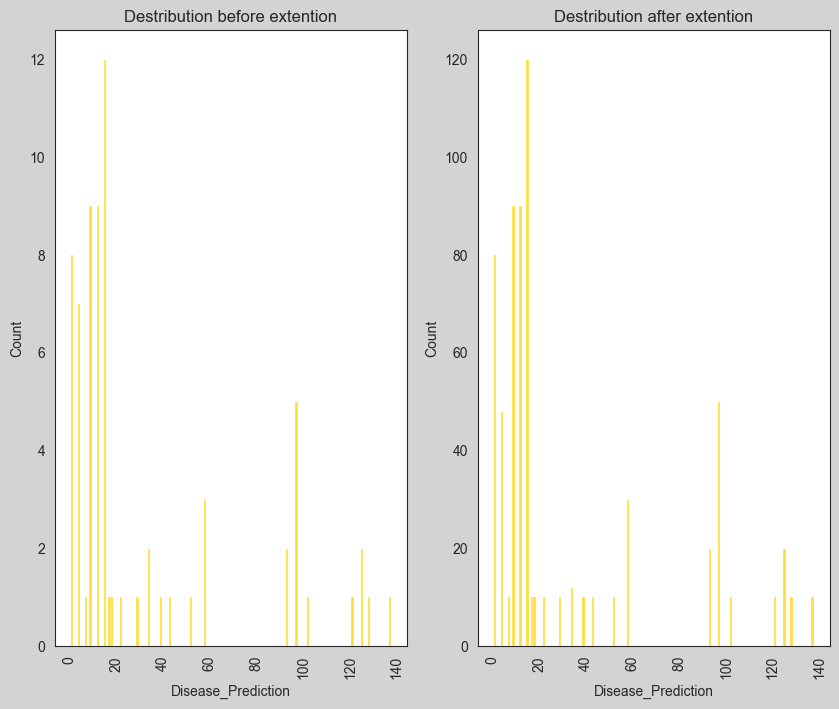

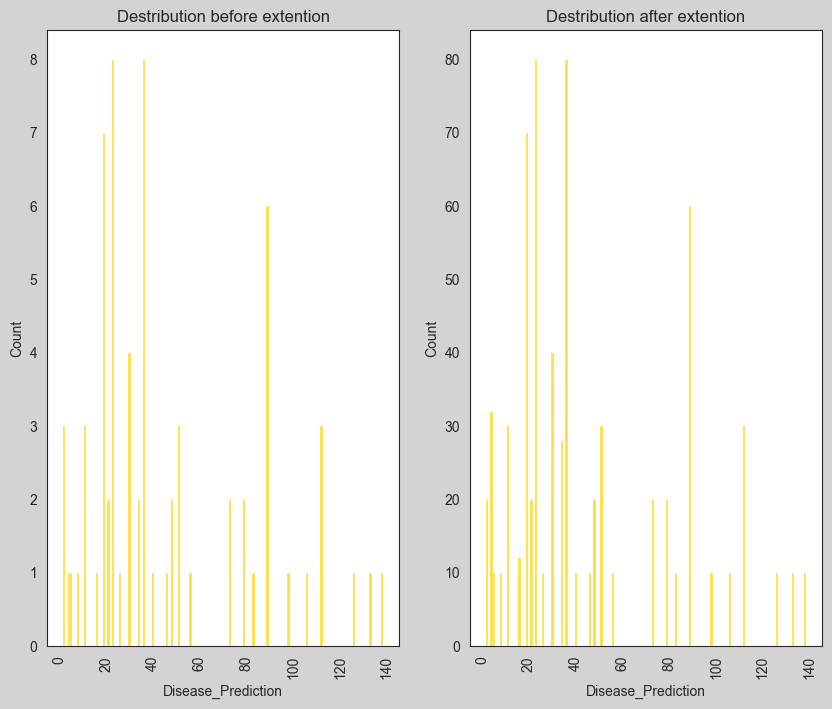

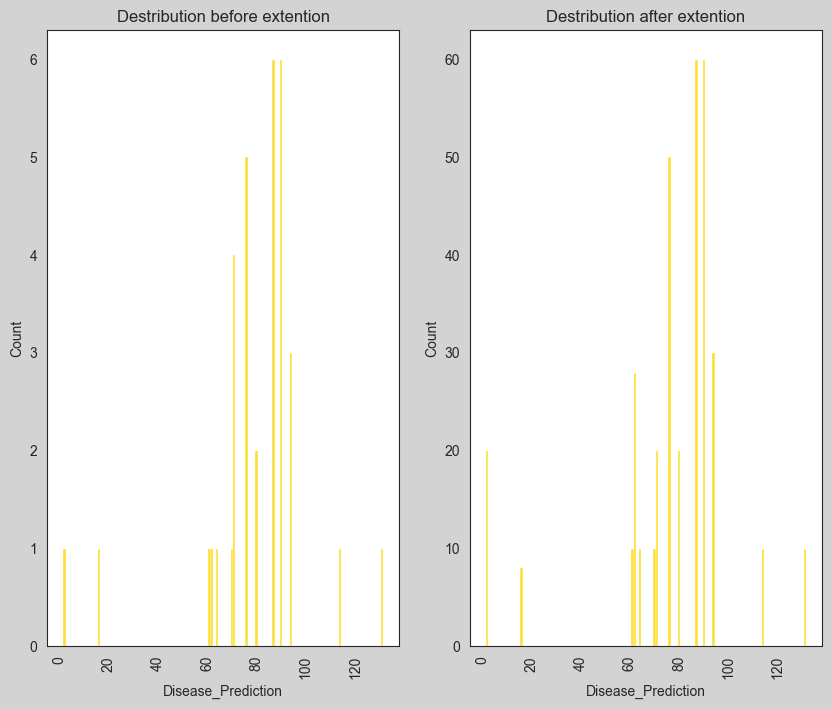

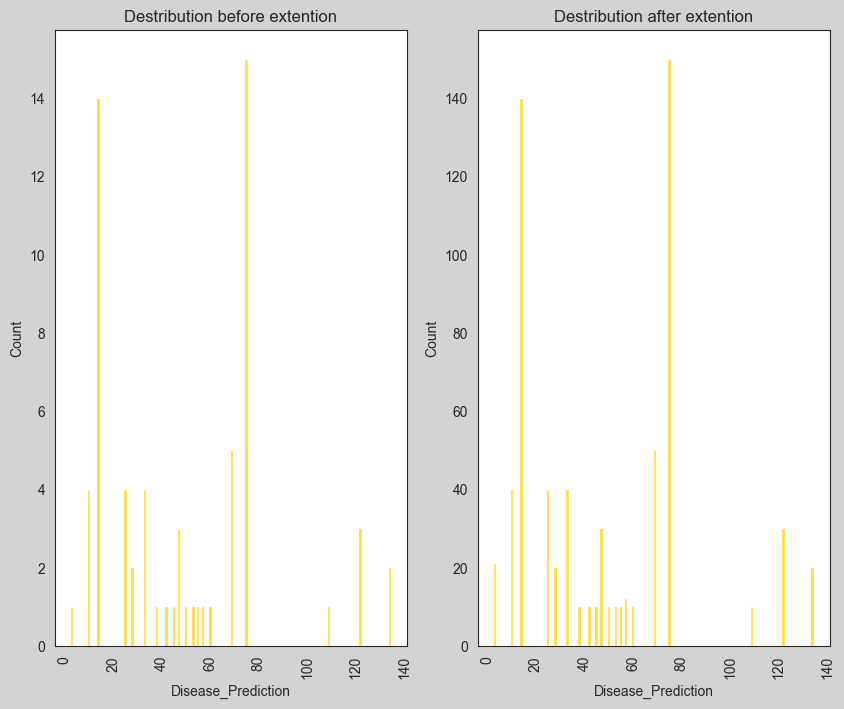

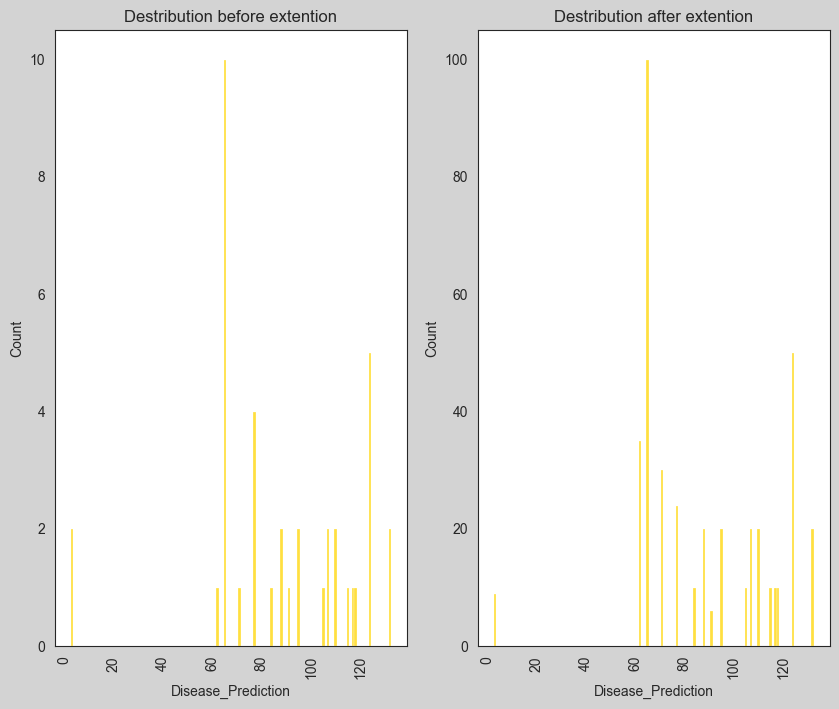

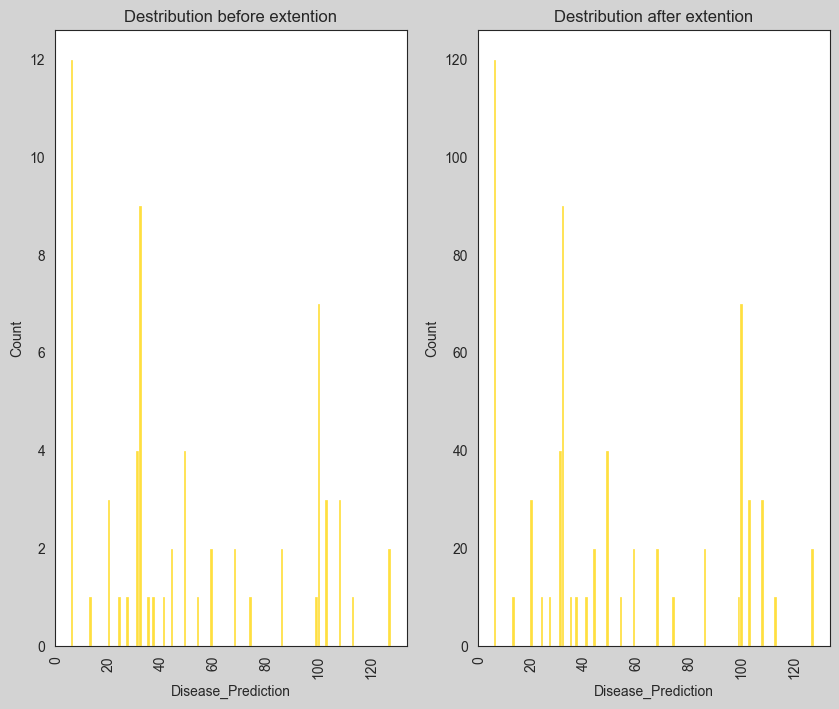

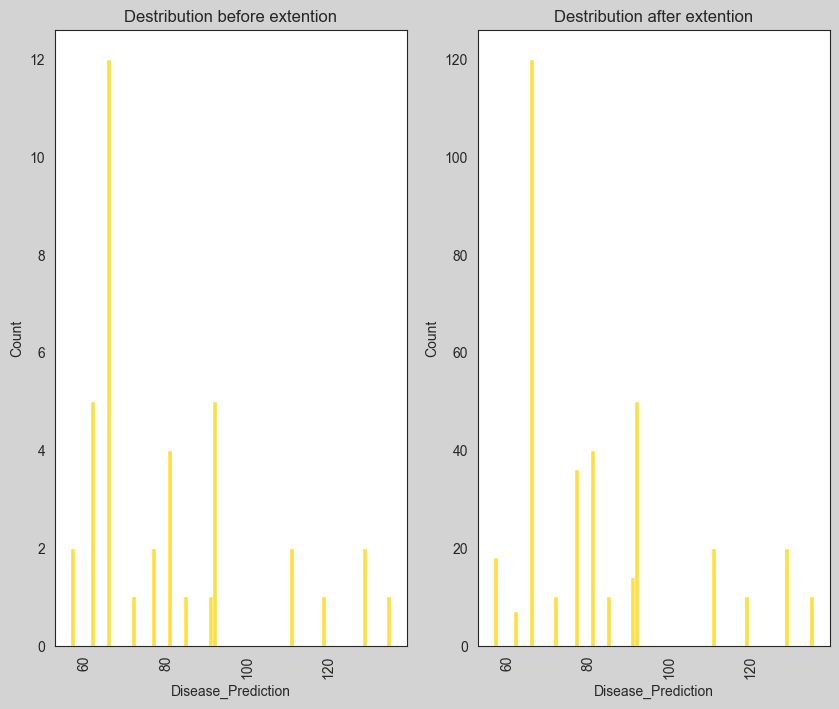

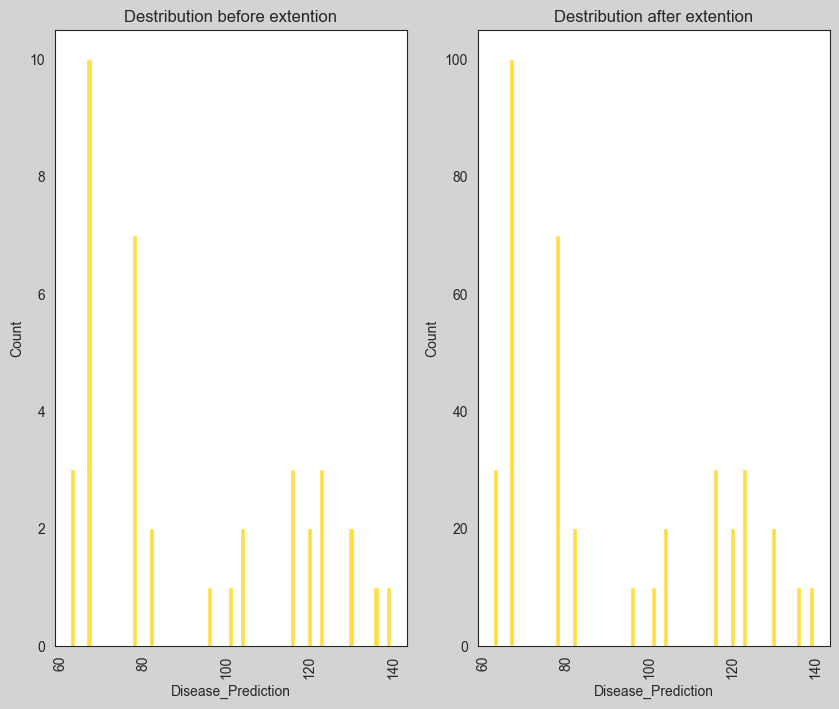

In [73]:
for animal_type in extended_animals['Animal_Type'].unique():
    before = a_copy[a_copy['Animal_Type'] == animal_type]
    after = extended_animals[extended_animals['Animal_Type'] == animal_type]
    
    plt.figure(figsize=(10, 8), facecolor='lightgrey')
    
    plt.subplot(1, 2, 1)
    
    sns.histplot(before, x='Disease_Prediction', discrete=True)
    plt.xticks(rotation=90)
    plt.title('Destribution before extention')
    
    plt.subplot(1, 2, 2)
    
    sns.histplot(after, x='Disease_Prediction', discrete=True)
    plt.xticks(rotation=90)
    plt.title('Destribution after extention')
    
    plt.show()

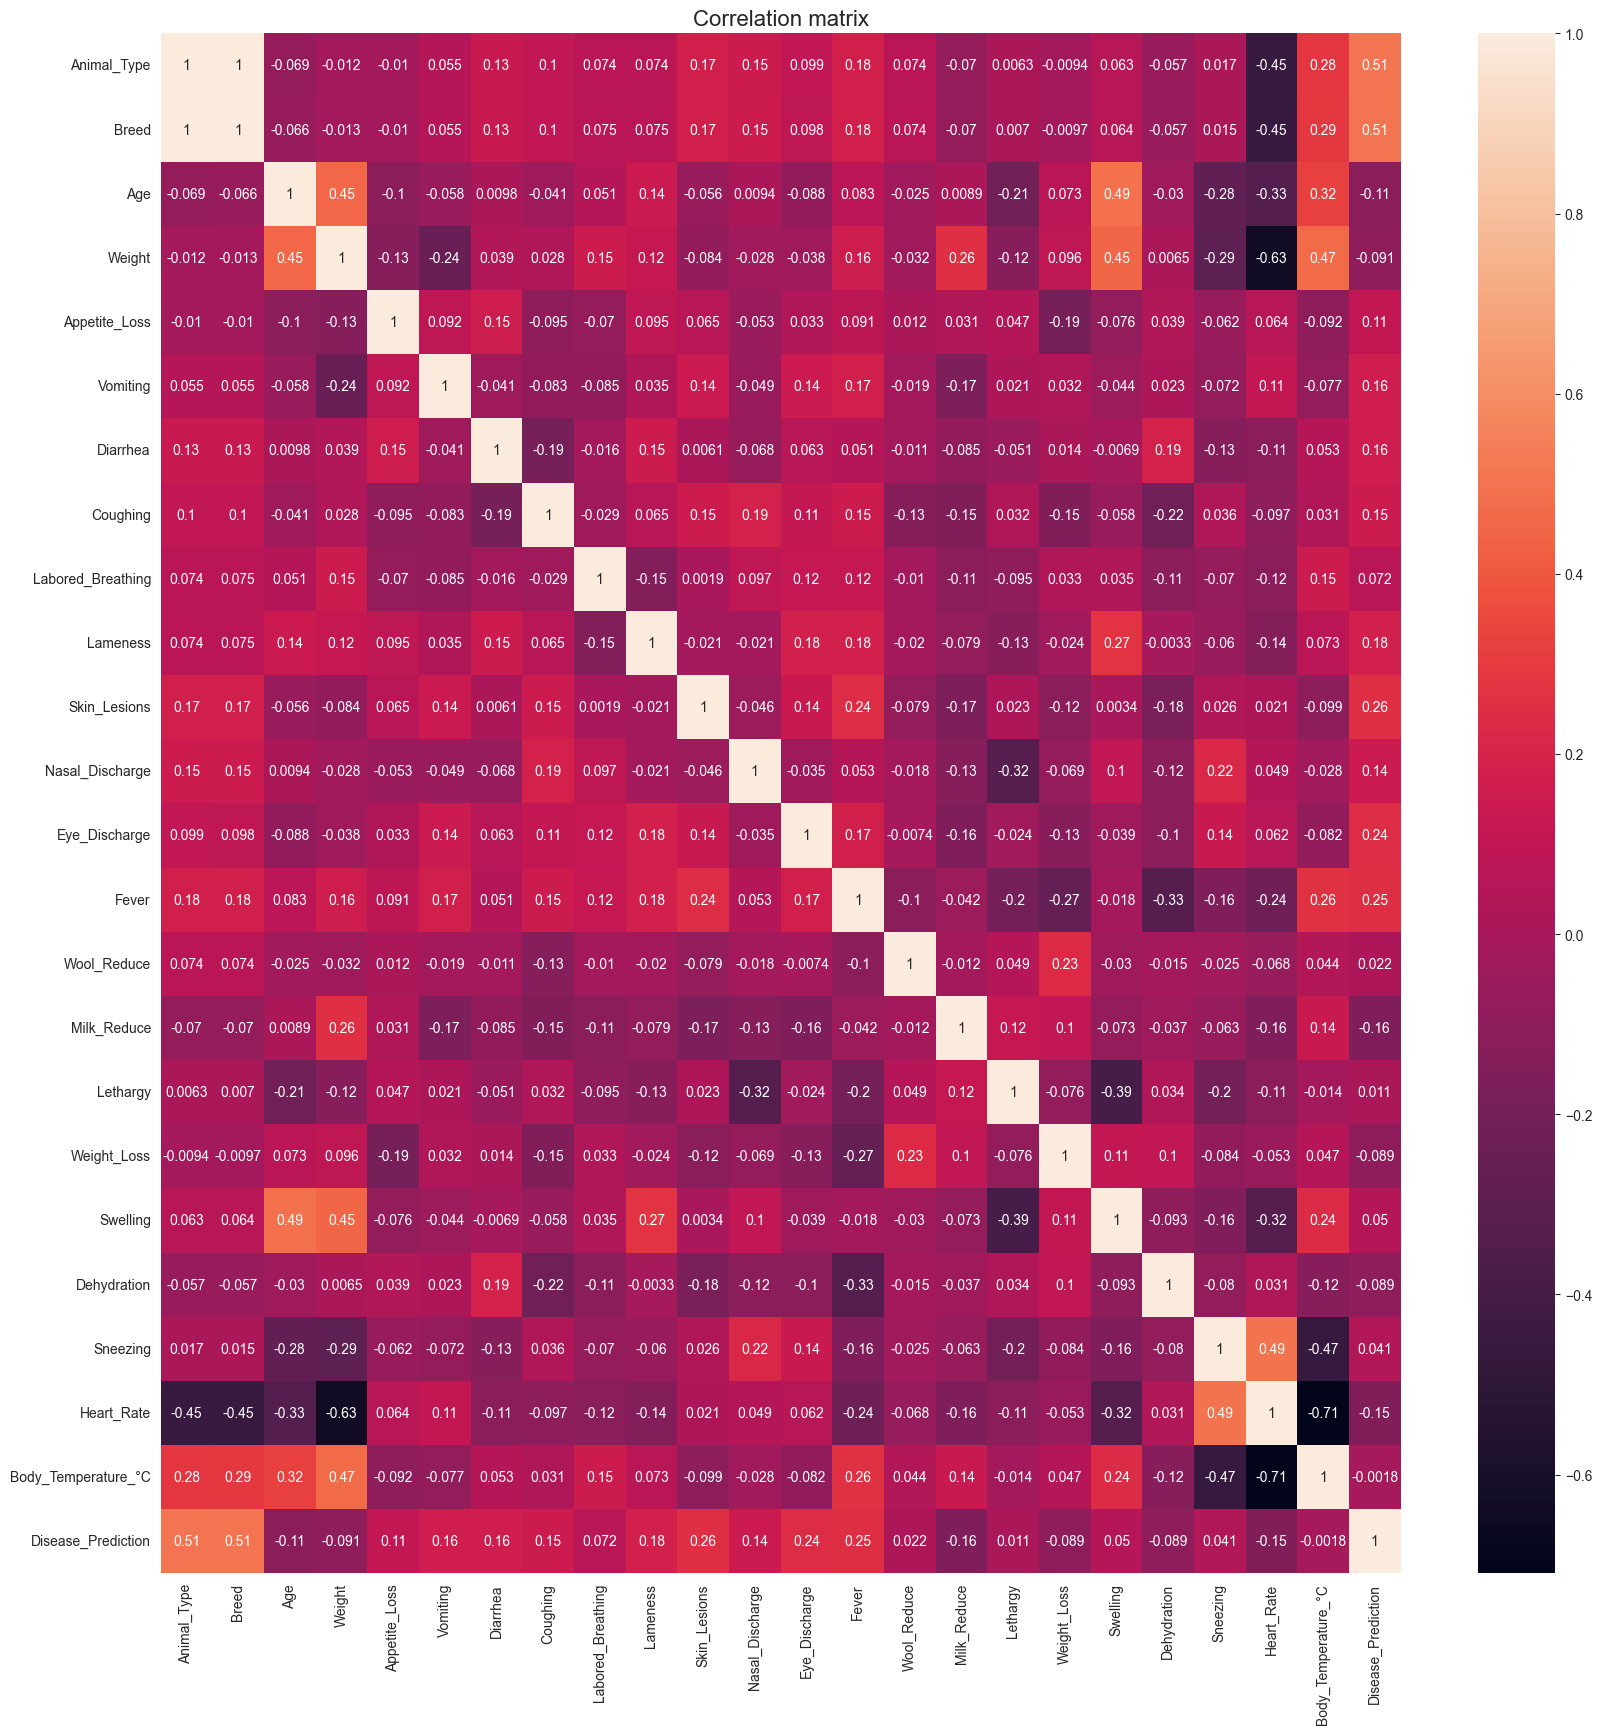

In [74]:
matrix = extended_animals.corr()

plt.figure(figsize=(20, 20))

sns.heatmap(matrix, annot=True)
plt.title('Correlation matrix', fontsize=16)

# plt.savefig('correlations_2.png', bbox_inches='tight')
plt.show()

### Drop unnecessary

In [75]:
extended_animals.drop(columns=['Age', 'Weight', 'Body_Temperature_°C'], inplace=True)

## Import necessary libraries    

In [76]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, roc_auc_score
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA

from another_transformers import AnimalImputer, NumericalImputer

## SPLIT

In [77]:
F = extended_animals.drop(columns=['Disease_Prediction'])
t = extended_animals['Disease_Prediction']

In [78]:
F_train, F_test, t_train, t_test = train_test_split(F, t, test_size=0.2, random_state=choice(range(1, 100)))
F_train.head()

,Animal_Type,Breed,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Fever,Wool_Reduce,Milk_Reduce,Lethargy,Weight_Loss,Swelling,Dehydration,Sneezing,Heart_Rate
1939,1,1.07,1,1,0,1,1,1,1,0,0,1,0,0,1,0,0,0,0,130
2076,8,8.03,1,1,0,1,1,0,1,1,0,0,0,0,1,0,0,0,0,85
3414,1,1.17,1,1,0,1,1,1,1,0,1,1,0,0,1,0,0,0,0,115
1982,5,5.03,1,1,1,1,0,1,1,1,1,1,0,0,1,0,0,0,0,85
762,3,3.11,1,1,0,1,1,1,1,0,1,1,0,0,1,0,0,0,0,80


## COLUMNS DEFINITION

In [79]:
f1 = ['Animal_Type', 'Breed', 'Heart_Rate']
f2 = [x for x in F_train.columns if x not in f1]
f2

['Appetite_Loss',
 'Vomiting',
 'Diarrhea',
 'Coughing',
 'Labored_Breathing',
 'Lameness',
 'Skin_Lesions',
 'Nasal_Discharge',
 'Eye_Discharge',
 'Fever',
 'Wool_Reduce',
 'Milk_Reduce',
 'Lethargy',
 'Weight_Loss',
 'Swelling',
 'Dehydration',
 'Sneezing']

## PIPELINES

In [80]:
first_pipe = Pipeline(steps=[('cats_impute', AnimalImputer()), ('nums_impute', NumericalImputer())])

scale_pipe = Pipeline(steps=[('scale', StandardScaler())])
still_pipe = Pipeline(steps=[('still_impute', SimpleImputer(strategy='constant', fill_value=0))])

In [81]:
col_trans = ColumnTransformer(transformers=[('scale', scale_pipe, f1), ('still', still_pipe, f2)])

In [82]:
gen_pipe = Pipeline(steps=[('impute', first_pipe), ('preproc', col_trans)])

In [83]:
res = gen_pipe.fit_transform(F_train)
df = pd.DataFrame(res, columns=gen_pipe.get_feature_names_out())
df

,scale__Animal_Type,scale__Breed,scale__Heart_Rate,still__Appetite_Loss,still__Vomiting,still__Diarrhea,still__Coughing,still__Labored_Breathing,still__Lameness,still__Skin_Lesions,still__Nasal_Discharge,still__Eye_Discharge,still__Fever,still__Wool_Reduce,still__Milk_Reduce,still__Lethargy,still__Weight_Loss,still__Swelling,still__Dehydration,still__Sneezing
0,-1.316898,-1.313284,0.882203,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.824576,1.820281,-0.730859,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-1.316898,-1.268261,0.344516,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.478230,0.469607,-0.730859,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-0.419334,-0.394825,-0.910088,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3363,-1.316898,-1.317786,1.061432,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3364,-1.316898,-1.335795,0.344516,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3365,0.029448,0.046395,-0.910088,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3366,-0.868116,-0.876566,1.491582,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## RANDOMFOREST

In [84]:
final = Pipeline(steps=[('preprocessing', gen_pipe), ('model', RandomForestClassifier())])
final.fit(F_train, t_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('preproc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cats_impute', ...), ('nums_impute', ...)]"
,"transform_i

In [85]:
pred = final.predict(F_test)
accuracy_score(t_test, pred)

0.9524940617577197

## Cross-validate evaluation

In [86]:
cross_val_score(final, F_train, t_train, cv=8, scoring='accuracy')

array([0.95961995, 0.95724466, 0.94774347, 0.96199525, 0.95249406,
       0.96199525, 0.94536817, 0.96437055])

In [1215]:
params = {
    'model__n_estimators': [20, 50, 100, 200],
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__max_depth': [3, 5, 10, 20],
    'model__min_samples_leaf': [1, 3, 5],
    'model__max_leaf_nodes': [None, 3, 5],
    'model__class_weight': ['balanced', 'balanced_subsample', None],
         }
f_grid = GridSearchCV(final, param_grid=params, scoring='accuracy', cv=4)
f_grid.fit(F_train, t_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced', 'balanced_subsample', ...], 'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [3, 5, ...], 'model__max_leaf_nodes': [None, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher,

In [1216]:
print(f'Best params: {f_grid.best_params_}')
print(f'Best score: {f_grid.best_score_}')

Best params: {'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 20, 'model__max_leaf_nodes': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best score: 0.9542755344418052


In [1218]:
f_model = f_grid.best_estimator_
f_pred = f_model.predict(F_test)
accuracy_score(t_test, f_pred)

0.9572446555819477

## MODEL EVALUATION

In [1219]:
for _ in range(5):
    F_train, F_test, t_train, t_test = train_test_split(F, t, test_size=0.25, random_state=np.random.randint(100, 10000))
    f_pred = f_model.predict(F_test)
    precision = precision_score(t_test, f_pred, average='macro')
    recall = recall_score(t_test, f_pred, average='macro')
    f1 = f1_score(t_test, f_pred, average='macro')
    print(f'Accuracy: {accuracy_score(t_test, f_pred)}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1 score: {f1}')
    print('*' * 20)

Accuracy: 0.9791073124406457
Precision: 0.9752501921680167
Recall: 0.982654707851265
F1 score: 0.9768407731297406
********************
Accuracy: 0.976258309591643
Precision: 0.9801704468371135
Recall: 0.9845814860902581
F1 score: 0.9789888835193387
********************
Accuracy: 0.9819563152896487
Precision: 0.9820485334370546
Recall: 0.9904048246439551
F1 score: 0.9834945649179108
********************
Accuracy: 0.9753086419753086
Precision: 0.9816675138195443
Recall: 0.9861949519121483
F1 score: 0.9829124054995555
********************
Accuracy: 0.976258309591643
Precision: 0.9765253405283683
Recall: 0.9876378708819078
F1 score: 0.979632253761083
********************


In [1220]:
test_sample = extended_animals.sample(300, ignore_index=True, random_state=7887)

In [1221]:
Features = test_sample.drop(columns=['Disease_Prediction'])
target = test_sample['Disease_Prediction']

In [1222]:
f_another_pred = f_model.predict(Features)

In [1223]:
precision = precision_score(target, f_another_pred, average='macro')
recall = recall_score(target, f_another_pred, average='macro')
f1 = f1_score(target, f_another_pred, average='macro')
roc = roc_auc_score(t, f_model.predict_proba(F), multi_class='ovr')
print(f'Accuracy: {accuracy_score(target, f_another_pred)}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 score: {f1}')
print(f'ROC-AUC score: {roc}')

Accuracy: 0.9733333333333334
Precision: 0.9755434782608695
Recall: 0.9864777432712215
F1 score: 0.9757475314540534
ROC-AUC score: 0.9998847467352806


### Confusion matrix

In [1224]:
conf_matrix = confusion_matrix(target, f_another_pred)
np.diag(conf_matrix).sum()

np.int64(292)

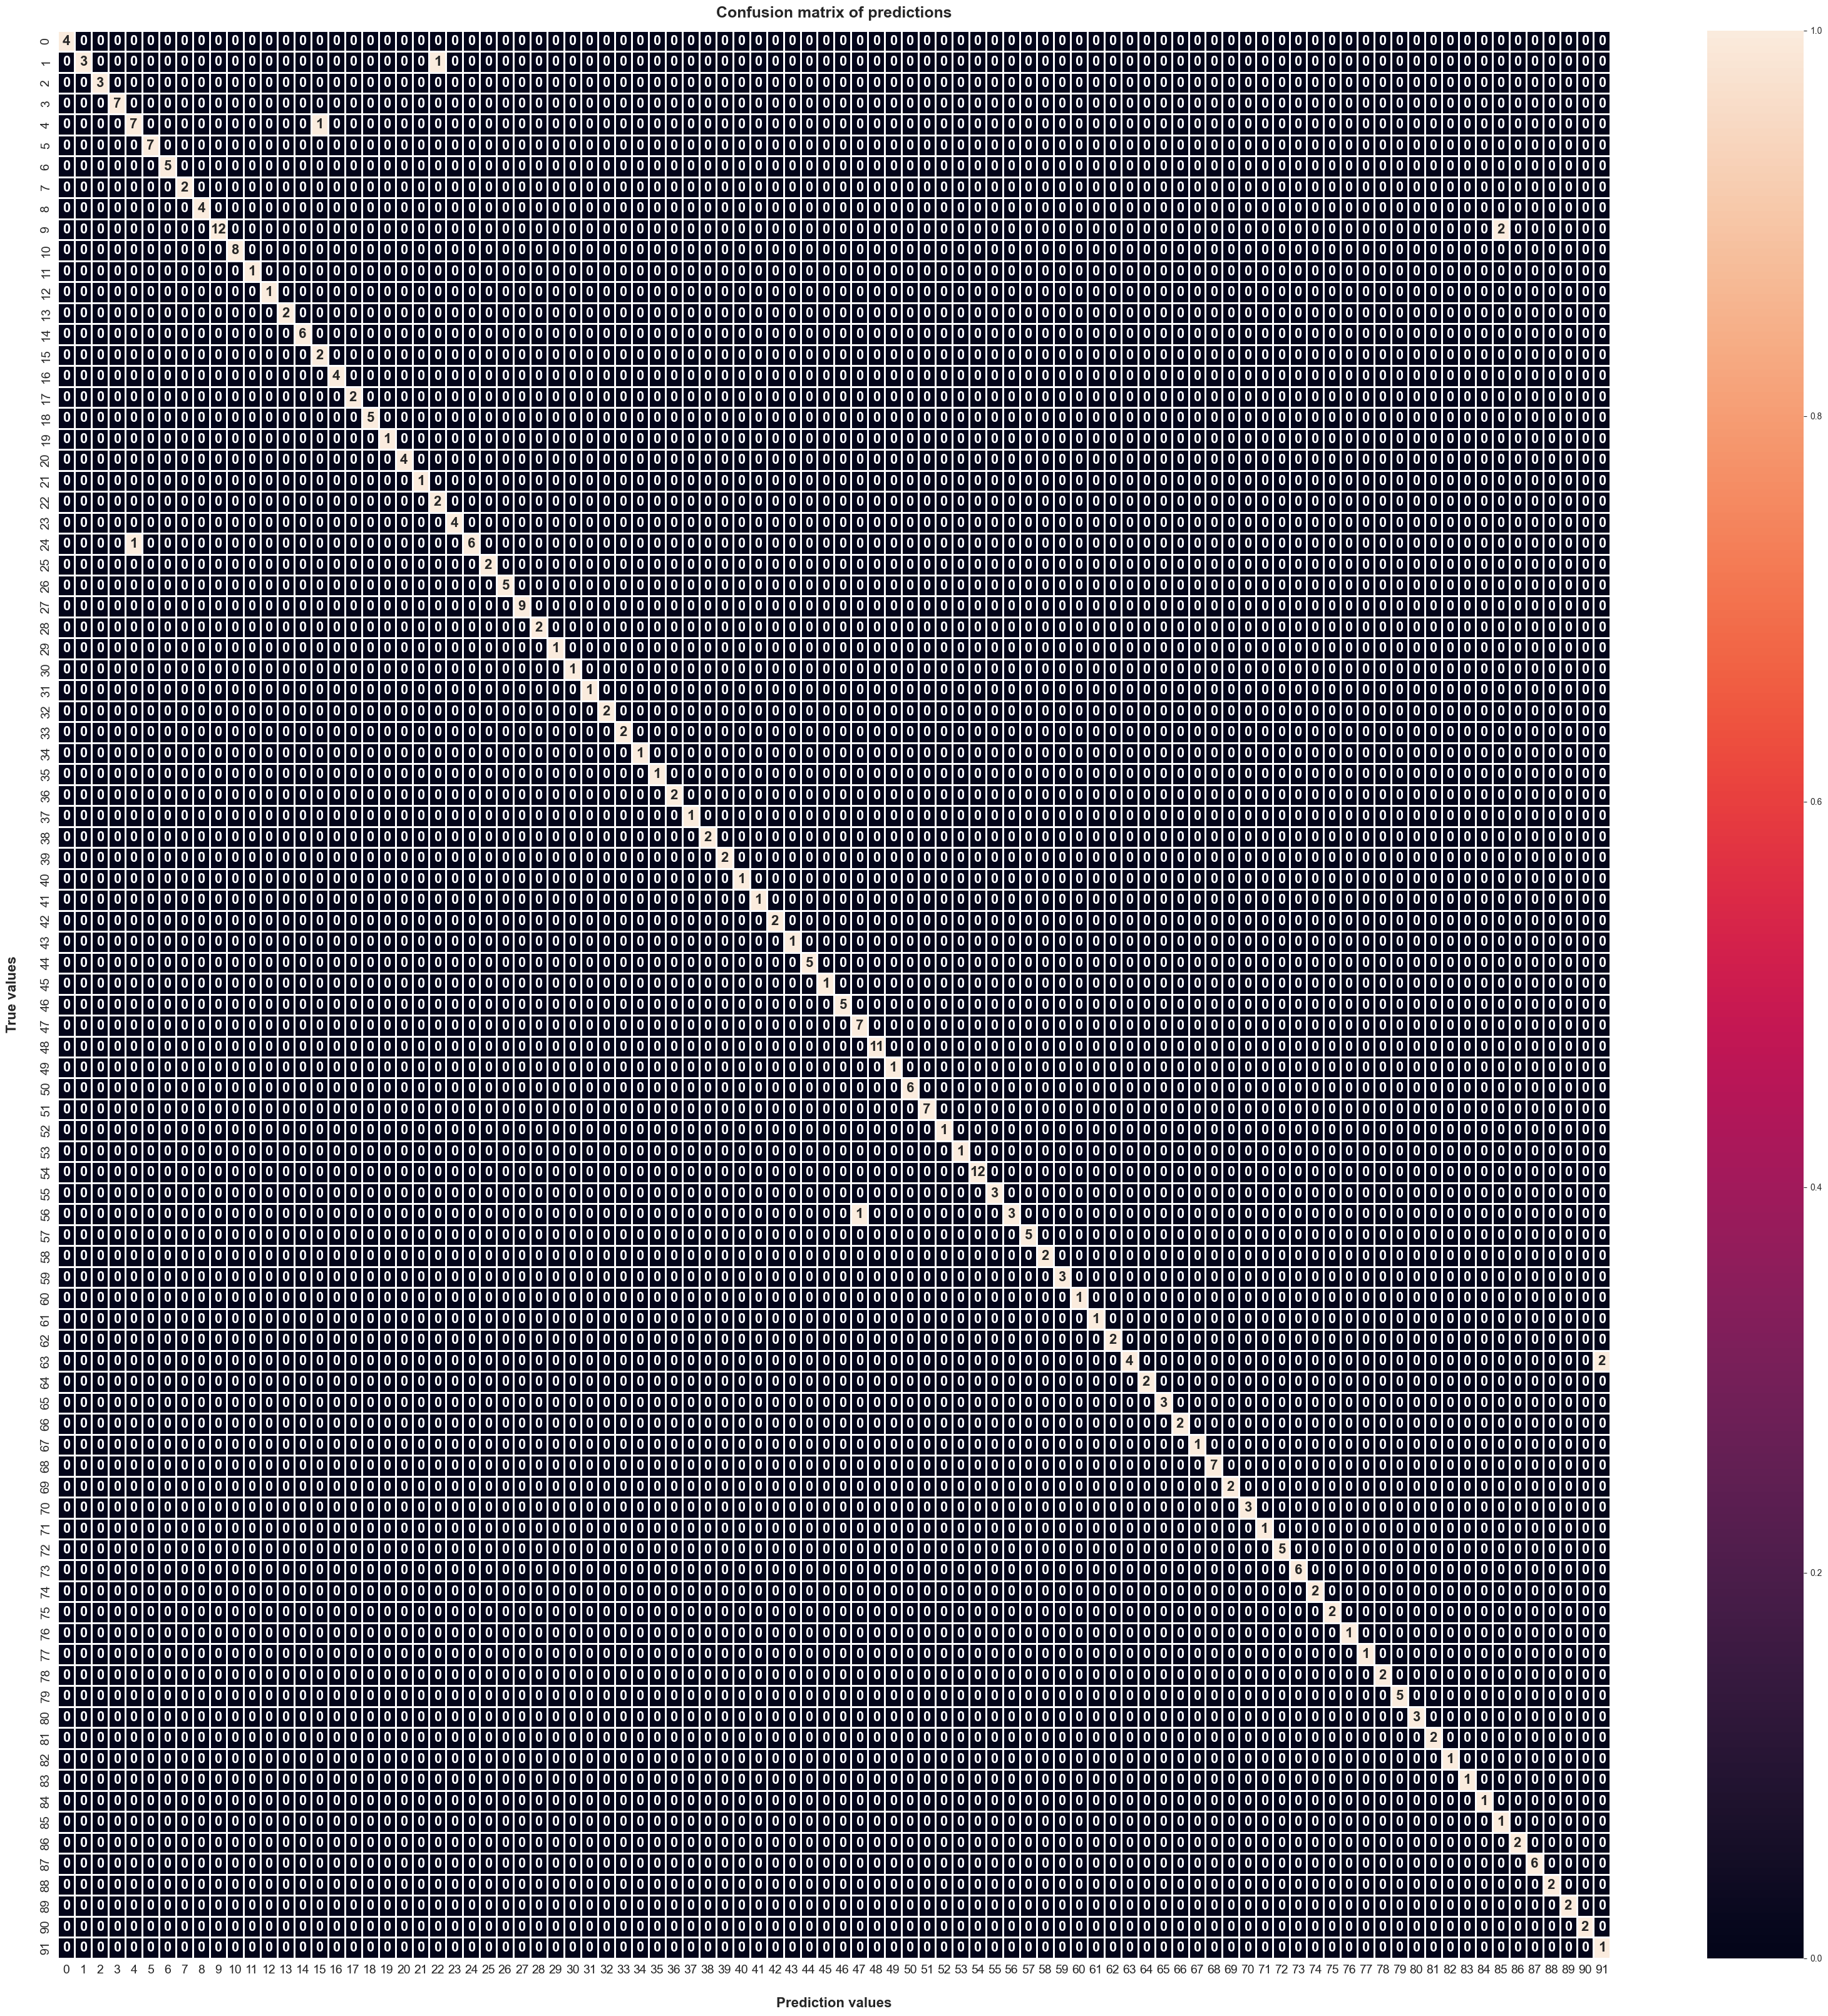

In [1225]:
plt.figure(figsize=(40, 40))

sns.heatmap(conf_matrix, annot=True, vmin=0, vmax=1, linewidth=1, annot_kws={'fontsize': 16, 'weight': 'bold'})

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Prediction values', fontsize=16, weight='bold', labelpad=25.0)
plt.ylabel('True values', fontsize=16, weight='bold', labelpad=25.0)
plt.title('Confusion matrix of predictions', fontsize=18, weight='bold', pad=15.0)

plt.savefig('confusions.png')
plt.show()

## KNN

In [87]:
F_train_2, F_test_2, t_train_2, t_test_2 = train_test_split(F, t, test_size=0.25, random_state=4757)

In [88]:
knn_pipe = Pipeline(steps=[('preprocessing', gen_pipe), ('knn', KNeighborsClassifier())])
knn_pipe.fit(F_train_2, t_train_2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('preproc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cats_impute', ...), ('nums_impute', ...)]"
,"transform_inp

In [89]:
k_pred = knn_pipe.predict(F_test_2)
accuracy_score(t_test_2, k_pred)

0.9544159544159544

In [90]:
knn_params = {'knn__n_neighbors': [2, 3, 5, 8, 9],
             'knn__weights': ['uniform', 'distance'],
             'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
             'knn__p': [1, 2, 4]}

k_grid = GridSearchCV(knn_pipe, param_grid=knn_params, cv=4, scoring='accuracy')
k_grid.fit(F_train_2, t_train_2)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__algorithm': ['auto', 'ball_tree', ...], 'knn__n_neighbors': [2, 3, ...], 'knn__p': [1, 2, ...], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [91]:
print(f'Best params: {k_grid.best_params_}')
print(f'Best score: {k_grid.best_score_}')

Best params: {'knn__algorithm': 'auto', 'knn__n_neighbors': 2, 'knn__p': 2, 'knn__weights': 'distance'}
Best score: 0.952801575460044


In [92]:
k_model = k_grid.best_estimator_

for _ in range(5):
    F_train, F_test, t_train, t_test = train_test_split(F, t, test_size=0.25, random_state=np.random.randint(100, 10000))
    k_pred = k_model.predict(F_test)
    print(accuracy_score(t_test, k_pred))

0.9781576448243114
0.9705603038936372
0.9677113010446344
0.9743589743589743
0.9696106362773029


In [93]:
test_sample = extended_animals.sample(300, ignore_index=True, random_state=5487)

In [94]:
Features = test_sample.drop(columns=['Disease_Prediction'])
target = test_sample['Disease_Prediction']

In [95]:
k_pred = k_model.predict(Features)

In [97]:
precision = precision_score(target, k_pred, average='macro')
recall = recall_score(target, k_pred, average='macro')
f1 = f1_score(target, k_pred, average='macro')
roc = roc_auc_score(t, k_model.predict_proba(F), multi_class='ovr')
print(f'Accuracy: {accuracy_score(target, k_pred)}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 score: {f1}')
print(f'ROC-AUC score: {roc}')

Accuracy: 0.98
Precision: 0.9786588029707296
Recall: 0.9793577981651376
F1 score: 0.9764435789544433
ROC-AUC score: 0.9954470027630216


## DECISIONTREE

In [98]:
F_train_3, F_test_3, t_train_3, t_test_3 = train_test_split(F, t, test_size=0.25, random_state=4751)

In [99]:
tree_pipe = Pipeline(steps=[('preprocessing', gen_pipe), ('tree', DecisionTreeClassifier())])
tree_pipe.fit(F_train_3, t_train_3)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('tree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('preproc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cats_impute', ...), ('nums_impute', ...)]"
,"transform_in

In [100]:
tree_pred = tree_pipe.predict(F_test_3)
accuracy_score(t_test_3, tree_pred)

0.9572649572649573

In [101]:
tree_p = {
    'tree__criterion': ["gini", "entropy", "log_loss"],
    'tree__splitter': ["best", "random"],
    'tree__max_depth': [2, 3, 5, 10],
    'tree__min_samples_split': [2, 5, 10],
    'tree__class_weight': ['balanced', None],
}
tree_grid = GridSearchCV(tree_pipe, param_grid=tree_p, scoring='accuracy', cv=4)
tree_grid.fit(F_train_3, t_train_3)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'tree__class_weight': ['balanced', None], 'tree__criterion': ['gini', 'entropy', ...], 'tree__max_depth': [2, 3, ...], 'tree__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [102]:
print(f'Best params: {tree_grid.best_params_}')
print(f'Best score: {tree_grid.best_score_}')

Best params: {'tree__class_weight': 'balanced', 'tree__criterion': 'log_loss', 'tree__max_depth': 10, 'tree__min_samples_split': 5, 'tree__splitter': 'random'}
Best score: 0.868858593637195


In [104]:
t_model = tree_grid.best_estimator_

test_sample_2 = extended_animals.sample(500, ignore_index=True)
Feat = test_sample_2.drop(columns=['Disease_Prediction'])
targ = test_sample_2['Disease_Prediction']
t_pred = t_model.predict(Feat)
precision = precision_score(targ, t_pred, average='macro')
recall = recall_score(targ, t_pred, average='macro')
f1 = f1_score(targ, t_pred, average='macro')
roc = roc_auc_score(t, t_model.predict_proba(F), multi_class='ovr')
print(f'Accuracy: {accuracy_score(targ, t_pred)}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 score: {f1}')
print(f'ROC-AUC score: {roc}')

Accuracy: 0.838
Precision: 0.8937613809514636
Recall: 0.9055963988207547
F1 score: 0.8813141338940813
ROC-AUC score: 0.9989510328237392


In [1250]:
import joblib
import pickle
import dill

In [490]:
with open('diseases.pkl', 'wb') as d:
    dill.dump(disease_rank, d)

In [493]:
breeds

{1: [(1, 'Beagle'),
  (2, 'Chihuahua'),
  (3, 'Golden Retriever'),
  (4, 'Poodle'),
  (5, 'German Shepherd'),
  (6, 'Bulldog'),
  (7, 'Rottweiler'),
  (8, 'Dachshund'),
  (9, 'Shih Tzu'),
  (10, 'Boxer'),
  (11, 'Labrador'),
  (12, 'Cocker Spaniel'),
  (13, 'Siberian Husky'),
  (14, 'Husky'),
  (15, 'Border Collie'),
  (16, 'Corgi'),
  (17, 'Dalmatian'),
  (18, 'Labrador Retriever'),
  (19, 'Akita'),
  (20, 'Pit Bull'),
  (21, 'Yorkshire Terrier'),
  (22, 'Doberman Pinscher')],
 2: [(1, 'Maine Coon'),
  (2, 'Persian'),
  (3, 'Bengal'),
  (4, 'Siamese'),
  (5, 'Abyssinian'),
  (6, 'Sphynx'),
  (7, 'Russian Blue'),
  (8, 'Scottish Fold'),
  (9, 'Ragdoll'),
  (10, 'British Shorthair'),
  (11, 'Siberian'),
  (12, 'Burmese'),
  (13, 'Devon Rex'),
  (14, 'Bombay'),
  (15, 'American Curl'),
  (16, 'Manx')],
 3: [(1, 'Jersey'),
  (2, 'Holstein'),
  (3, 'Angus'),
  (4, 'Guernsey'),
  (5, 'Hereford'),
  (6, 'Simmental'),
  (7, 'Ayrshire'),
  (8, 'Charolais'),
  (9, 'Limousin'),
  (10, 'Brahman')

In [494]:
with open('breeds.pkl', 'wb') as b:
    dill.dump(breeds, b)

In [495]:
animals_rank

{'Dog': 1,
 'Cat': 2,
 'Cow': 3,
 'Horse': 4,
 'Rabbit': 5,
 'Sheep': 6,
 'Goat': 7,
 'Pig': 8}

In [496]:
with open('animals_by_number.pkl', 'wb') as a:
    dill.dump(animals_rank, a)

In [1254]:
with open('Final_Forest.pkl', 'wb') as forest:
    dill.dump(f_model, forest)

In [1255]:
with open('Final_KNN.pkl', 'wb') as knn:
    dill.dump(k_model, knn)

In [1256]:
with open('Final_Tree.pkl', 'wb') as tree:
    dill.dump(t_model, tree)

In [1259]:
with open('animals.pkl', 'wb') as a:
    dill.dump(extended_animals, a)